# Task 2 – Fine-Tuning BERT (base) on 20 Newsgroups

**Dataset:** `sklearn.datasets.fetch_20newsgroups`  
**Model:** `bert-base-uncased`  
**Goal:** Fine-tune BERT for 20-class text classification

---

## Tools Used
| Tool | Purpose |
|------|---------|
| `transformers` (HuggingFace) | BERT model & tokenizer |
| `torch` (PyTorch) | Training loop, DataLoader |
| `scikit-learn` | Dataset & evaluation metrics |
| `wandb` (Weights & Biases) | Experiment tracking — metrics, plots, model artifacts |
| `matplotlib` / `seaborn` | Local figure generation |
| AI assistance | Claude (Anthropic) — code scaffolding |

## Weights & Biases Dashboard
> **Paste your public W&B run URL here after the first training run:**  
> `https://wandb.ai/likhita-kolli-hochschule-luzern/nalapro-task2-bert/runs/ssv04uya`

---

## Cell 0 — Install Weights & Biases

In [4]:
# Run this cell first — only needed once per Colab session
!pip install wandb -q
print("wandb installed")

wandb installed


## Cell 1 — Imports & Configuration

In [5]:
# Must come BEFORE any matplotlib import — fixes OSError on Windows/OneDrive
import os
os.environ["MPLBACKEND"] = "Agg"

import time
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.datasets import fetch_20newsgroups
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    get_linear_schedule_with_warmup,
)

import wandb

# ── Reproducibility ───────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ── Device: GPU if available, else CPU ────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

# ── Hyperparameters ───────────────────────────────────────────────
MODEL_NAME   = "bert-base-uncased"
MAX_LEN      = 128    # tokens per sample (pad / truncate)
BATCH_SIZE   = 16
NUM_EPOCHS   = 3
LR           = 2e-5
WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.1
DROPOUT      = 0.1
NUM_CLASSES  = 20

# ── W&B project name ─────────────────────────────────────────────
WANDB_PROJECT = "nalapro-task2-bert"

# ── Output folders ────────────────────────────────────────────────
FIGURES_DIR = "figures"
MODELS_DIR  = "models"
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(MODELS_DIR,  exist_ok=True)

print(f"Model={MODEL_NAME} | max_len={MAX_LEN} | batch={BATCH_SIZE} | epochs={NUM_EPOCHS} | lr={LR}")

Device: cuda
Model=bert-base-uncased | max_len=128 | batch=16 | epochs=3 | lr=2e-05


## Cell 2 — W&B Login & Run Initialisation

In [6]:
# ── Login ─────────────────────────────────────────────────────────
# First time: go to https://wandb.ai/authorize, copy your API key,
# and paste it when prompted below.
wandb.login()

# ── Initialise a new W&B run ──────────────────────────────────────
# This creates a run on wandb.ai and prints a public URL.
# Paste that URL into the header markdown cell at the top of this notebook.
run = wandb.init(
    project=WANDB_PROJECT,
    name=f"bert-base_ep{NUM_EPOCHS}_lr{LR}",
    tags=["bert", "fine-tuning", "20newsgroups"],
    config={
        # All hyperparameters logged here appear in the W&B Config tab
        "model":        MODEL_NAME,
        "max_len":      MAX_LEN,
        "batch_size":   BATCH_SIZE,
        "num_epochs":   NUM_EPOCHS,
        "lr":           LR,
        "weight_decay": WEIGHT_DECAY,
        "warmup_ratio": WARMUP_RATIO,
        "dropout":      DROPOUT,
        "num_classes":  NUM_CLASSES,
        "seed":         SEED,
        "device":       str(DEVICE),
        "remove_meta":  "headers,footers,quotes",
    },
)

print(f"\nW&B Run URL  : {run.url}")
print(f"W&B Run Name : {run.name}")
print("\n>>> PASTE THE URL ABOVE INTO THE HEADER MARKDOWN CELL <<<")

wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: likhita-kolli (likhita-kolli-hochschule-luzern) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin



W&B Run URL  : https://wandb.ai/likhita-kolli-hochschule-luzern/nalapro-task2-bert/runs/hw85yqc0
W&B Run Name : bert-base_ep3_lr2e-05

>>> PASTE THE URL ABOVE INTO THE HEADER MARKDOWN CELL <<<


## Cell 3 — Load Data

In [7]:
# Remove metadata so the model learns from content, not sender/thread info
remove = ("headers", "footers", "quotes")

train_raw = fetch_20newsgroups(subset="train", remove=remove, random_state=SEED)
test_raw  = fetch_20newsgroups(subset="test",  remove=remove, random_state=SEED)

train_texts  = train_raw.data
train_labels = train_raw.target
test_texts   = test_raw.data
test_labels  = test_raw.target
TARGET_NAMES = train_raw.target_names

# Split 10% of training data into a validation set
train_texts, val_texts, train_labels, val_labels = train_test_split(
    train_texts, train_labels,
    test_size=0.1,
    random_state=SEED,
    stratify=train_labels,    # keeps class proportions equal in both splits
)

# Log dataset sizes to W&B config
wandb.config.update({
    "train_samples": len(train_texts),
    "val_samples":   len(val_texts),
    "test_samples":  len(test_texts),
})

print(f"Train: {len(train_texts)} | Val: {len(val_texts)} | Test: {len(test_texts)}")
print(f"Classes: {NUM_CLASSES}")

Train: 10182 | Val: 1132 | Test: 7532
Classes: 20


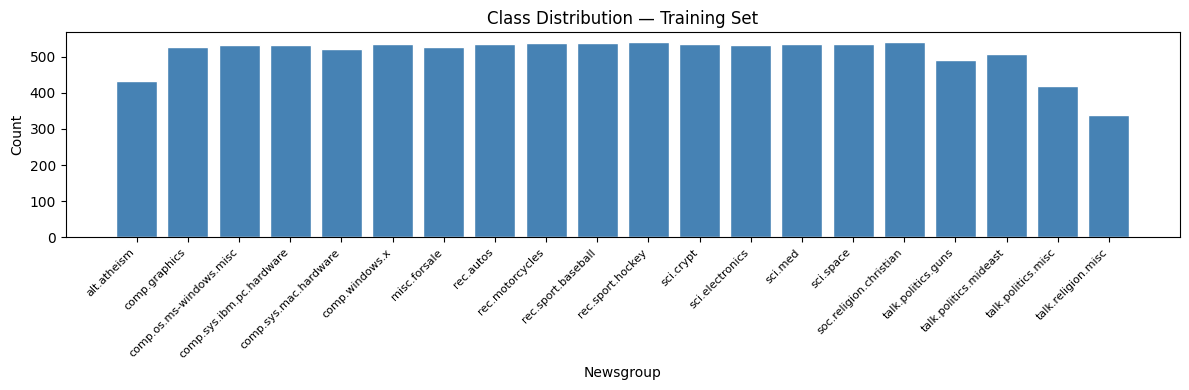

Saved & logged to W&B: figures/task2_class_distribution.png


In [8]:
# ── Class distribution bar chart ──────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4))
unique, counts = np.unique(train_labels, return_counts=True)
ax.bar([TARGET_NAMES[i] for i in unique], counts, color="steelblue", edgecolor="white")
ax.set_title("Class Distribution — Training Set")
ax.set_xlabel("Newsgroup")
ax.set_ylabel("Count")
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.tight_layout()
fig_path = os.path.join(FIGURES_DIR, "task2_class_distribution.png")
plt.savefig(fig_path, dpi=150)
plt.show()

# Log the figure to W&B — visible in the Media tab
wandb.log({"class_distribution": wandb.Image(fig_path)})
print(f"Saved & logged to W&B: {fig_path}")

## Cell 4 — Tokenization & Dataset

In [9]:
tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)


class NewsGroupDataset(Dataset):
    """
    PyTorch Dataset for 20 Newsgroups.

    Converts each raw text string into a dictionary of tensors
    (input_ids, attention_mask, label) that BERT can consume directly.

    Args:
        texts     : list of raw text strings
        labels    : array of integer class indices (0-19)
        tokenizer : HuggingFace BertTokenizer
        max_len   : pad / truncate all sequences to this length
    """

    def __init__(self, texts, labels, tokenizer, max_len=MAX_LEN):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        # DataLoader calls this to know when one epoch ends
        return len(self.texts)

    def __getitem__(self, idx):
        # Called once per sample — tokenise and return tensors
        encoding = self.tokenizer(
            str(self.texts[idx]),
            add_special_tokens=True,    # adds [CLS] at start, [SEP] at end
            max_length=self.max_len,
            padding="max_length",       # pad short texts with [PAD] tokens
            truncation=True,            # cut long texts at max_len
            return_attention_mask=True, # 1 for real tokens, 0 for padding
            return_tensors="pt",         # return PyTorch tensors
        )
        return {
            # squeeze removes the batch dimension added by the tokenizer
            "input_ids":      encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "label":          torch.tensor(self.labels[idx], dtype=torch.long),
        }


def make_loader(texts, labels, shuffle=False, max_len=MAX_LEN):
    """Wrap texts + labels in a DataLoader."""
    ds = NewsGroupDataset(texts, labels, tokenizer, max_len)
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle, num_workers=0)


train_loader = make_loader(train_texts, train_labels, shuffle=True)
val_loader   = make_loader(val_texts,   val_labels)
test_loader  = make_loader(test_texts,  test_labels)

print(f"Train batches: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Train batches: 637 | Val: 71 | Test: 471


## Cell 5 — Model, Optimizer & Scheduler

In [10]:
# Load pre-trained BERT with a 768→20 classification head on top
model = BertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_CLASSES,
    hidden_dropout_prob=DROPOUT,
    attention_probs_dropout_prob=DROPOUT,
).to(DEVICE)

# Tell W&B to watch the model — logs gradient histograms each epoch
# log='all'   → log both gradients AND parameter weights
# log_freq=1  → log every epoch (set higher to reduce overhead)
wandb.watch(model, log="all", log_freq=len(train_loader))

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params    : {total_params:,}")
print(f"Trainable params: {trainable_params:,}")

# Log model size to W&B
wandb.config.update({"total_params": total_params, "trainable_params": trainable_params})

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total params    : 109,497,620
Trainable params: 109,497,620


In [11]:
# Weight decay excluded from bias and LayerNorm — BERT paper recommendation
no_decay = ["bias", "LayerNorm.weight"]
optimizer = AdamW(
    [
        {"params": [p for n, p in model.named_parameters()
                    if not any(nd in n for nd in no_decay)],
         "weight_decay": WEIGHT_DECAY},
        {"params": [p for n, p in model.named_parameters()
                    if any(nd in n for nd in no_decay)],
         "weight_decay": 0.0},
    ],
    lr=LR, eps=1e-8,
)

# Linear warmup for first 10% of steps, then linear decay to 0
total_steps  = len(train_loader) * NUM_EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)
scheduler    = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps,
)
print(f"Total steps: {total_steps} | Warmup: {warmup_steps}")

Total steps: 1911 | Warmup: 191


## Cell 6 — Training & Evaluation Functions

In [12]:
def train_one_epoch(model, loader, optimizer, scheduler):
    """
    One full pass through the training data.

    For each batch:
      1. Forward pass  → compute loss
      2. Backward pass → compute gradients
      3. Clip gradients (stability)
      4. Update weights
      5. Advance LR scheduler

    Returns:
        avg_loss (float), accuracy (float)
    """
    model.train()   # enables dropout
    total_loss, correct, total = 0.0, 0, 0

    for batch in loader:
        input_ids      = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        labels         = batch["label"].to(DEVICE)

        optimizer.zero_grad()   # clear gradients from previous batch

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels,      # model computes cross-entropy loss internally
        )

        loss = outputs.loss
        loss.backward()         # compute gradients via backpropagation

        # Prevent exploding gradients — rescale if total norm > 1.0
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()        # update weights
        scheduler.step()        # adjust learning rate

        total_loss += loss.item()
        preds       = outputs.logits.argmax(dim=-1)   # highest score = predicted class
        correct    += (preds == labels).sum().item()
        total      += labels.size(0)

    return total_loss / len(loader), correct / total


@torch.no_grad()   # no gradient computation needed during evaluation
def evaluate(model, loader):
    """
    Evaluate model on a DataLoader without updating weights.

    Returns:
        avg_loss (float), accuracy (float),
        all_preds (np.ndarray), all_labels (np.ndarray)
    """
    model.eval()   # disables dropout
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []

    for batch in loader:
        input_ids      = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        labels         = batch["label"].to(DEVICE)

        outputs     = model(input_ids=input_ids,
                            attention_mask=attention_mask,
                            labels=labels)
        total_loss += outputs.loss.item()
        preds       = outputs.logits.argmax(dim=-1)
        correct    += (preds == labels).sum().item()
        total      += labels.size(0)

        # Collect predictions and labels for sklearn metrics
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    return (
        total_loss / len(loader),
        correct / total,
        np.array(all_preds),
        np.array(all_labels),
    )

## Cell 7 — Training Loop

In [13]:
# Storage for plotting training curves after training completes
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

best_val_acc    = 0.0
best_model_path = os.path.join(MODELS_DIR, "bert_best.pt")

print(f"Training for {NUM_EPOCHS} epochs...\n")

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()

    # ── Train ────────────────────────────────────────────────────
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, scheduler)

    # ── Validate ─────────────────────────────────────────────────
    val_loss, val_acc, _, _ = evaluate(model, val_loader)

    elapsed = time.time() - t0

    # Store for local training curve plot
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    # ── Log metrics to W&B ───────────────────────────────────────
    # These appear as live time-series charts in the W&B dashboard
    wandb.log({
        "epoch":           epoch,
        "train/loss":      train_loss,   # W&B groups metrics with / into sections
        "train/accuracy":  train_acc,
        "val/loss":        val_loss,
        "val/accuracy":    val_acc,
        "epoch_time_sec":  elapsed,
        "learning_rate":   scheduler.get_last_lr()[0],  # current LR after scheduler step
    })

    print(
        f"Epoch {epoch}/{NUM_EPOCHS} | "
        f"Train Loss: {train_loss:.4f}  Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f}  Acc: {val_acc:.4f} | "
        f"{elapsed:.1f}s"
    )

    # Save checkpoint only when validation accuracy improves
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_model_path)
        wandb.log({"best_val_accuracy": best_val_acc, "epoch": epoch})
        print(f"  ✓ Best model saved (val_acc={val_acc:.4f})")

print(f"\nTraining complete. Best val_acc: {best_val_acc:.4f}")

Training for 3 epochs...

Epoch 1/3 | Train Loss: 1.8495  Acc: 0.4813 | Val Loss: 1.0590  Acc: 0.6935 | 253.6s
  ✓ Best model saved (val_acc=0.6935)
Epoch 2/3 | Train Loss: 0.8884  Acc: 0.7407 | Val Loss: 0.8890  Acc: 0.7341 | 255.7s
  ✓ Best model saved (val_acc=0.7341)
Epoch 3/3 | Train Loss: 0.6254  Acc: 0.8246 | Val Loss: 0.8458  Acc: 0.7553 | 256.3s
  ✓ Best model saved (val_acc=0.7553)

Training complete. Best val_acc: 0.7553


## Cell 8 — Training Curves (local + W&B)

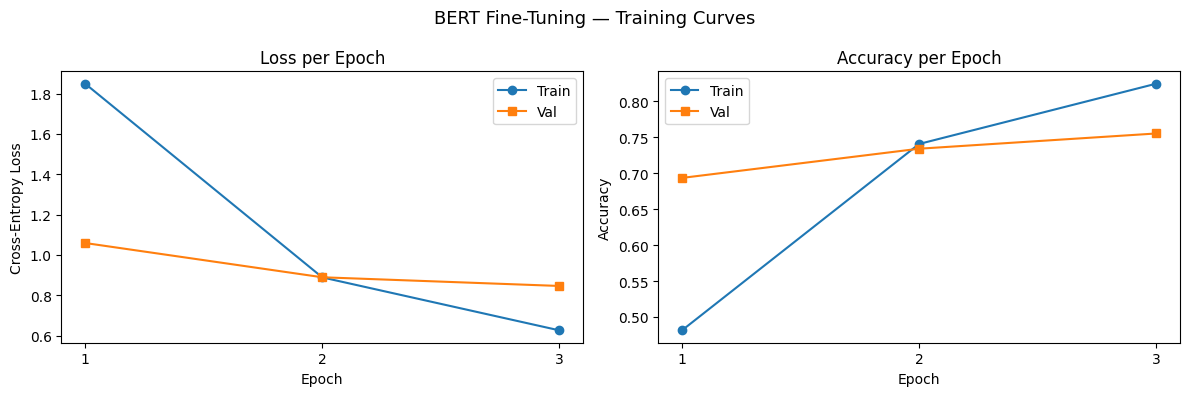

Saved & logged: figures/task2_bert_training_curves.png


In [14]:
epochs_range = range(1, NUM_EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss plot
axes[0].plot(epochs_range, history["train_loss"], marker="o", label="Train")
axes[0].plot(epochs_range, history["val_loss"],   marker="s", label="Val")
axes[0].set_title("Loss per Epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-Entropy Loss")
axes[0].legend()
axes[0].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

# Accuracy plot
axes[1].plot(epochs_range, history["train_acc"], marker="o", label="Train")
axes[1].plot(epochs_range, history["val_acc"],   marker="s", label="Val")
axes[1].set_title("Accuracy per Epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

plt.suptitle("BERT Fine-Tuning — Training Curves", fontsize=13)
plt.tight_layout()
curve_path = os.path.join(FIGURES_DIR, "task2_bert_training_curves.png")
plt.savefig(curve_path, dpi=150)
plt.show()

# Log static figure to W&B Media tab
wandb.log({"training_curves": wandb.Image(curve_path)})
print(f"Saved & logged: {curve_path}")

## Cell 9 — Test Evaluation

In [15]:
# Load best checkpoint and evaluate on the held-out test set
model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))

test_loss, test_acc, test_preds, test_labels_arr = evaluate(model, test_loader)

macro_f1    = f1_score(test_labels_arr, test_preds, average="macro")
weighted_f1 = f1_score(test_labels_arr, test_preds, average="weighted")

print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc:.4f}")
print(f"Macro F1      : {macro_f1:.4f}")
print(f"Weighted F1   : {weighted_f1:.4f}")
print()
report_str = classification_report(test_labels_arr, test_preds, target_names=TARGET_NAMES)
print(report_str)

# ── Log final test metrics to W&B summary ────────────────────────
# wandb.summary values appear in the project table for easy comparison
wandb.summary["test/loss"]        = test_loss
wandb.summary["test/accuracy"]    = test_acc
wandb.summary["test/macro_f1"]    = macro_f1
wandb.summary["test/weighted_f1"] = weighted_f1

# Log the classification report as a W&B Table (searchable in dashboard)
rows = []
for i, name in enumerate(TARGET_NAMES):
    mask = test_labels_arr == i
    if mask.sum() > 0:
        p = (test_preds[mask] == i).sum() / (test_preds == i).sum() if (test_preds == i).sum() > 0 else 0
        r = (test_preds[mask] == i).sum() / mask.sum()
        f = 2 * p * r / (p + r) if (p + r) > 0 else 0
        rows.append([name, round(float(p), 4), round(float(r), 4), round(float(f), 4), int(mask.sum())])

report_table = wandb.Table(
    columns=["Class", "Precision", "Recall", "F1", "Support"],
    data=rows
)
wandb.log({"classification_report": report_table})

# Log the best model weights as a W&B Artifact
artifact = wandb.Artifact("bert-best-model", type="model",
                           description="Best BERT checkpoint by val accuracy")
artifact.add_file(best_model_path)
wandb.log_artifact(artifact)

print("\nTest metrics, classification table, and model artifact logged to W&B.")

Test Loss     : 1.0328
Test Accuracy : 0.6986
Macro F1      : 0.6811
Weighted F1   : 0.6954

                          precision    recall  f1-score   support

             alt.atheism       0.44      0.47      0.46       319
           comp.graphics       0.68      0.69      0.68       389
 comp.os.ms-windows.misc       0.67      0.64      0.66       394
comp.sys.ibm.pc.hardware       0.64      0.65      0.65       392
   comp.sys.mac.hardware       0.77      0.68      0.72       385
          comp.windows.x       0.80      0.77      0.79       395
            misc.forsale       0.82      0.85      0.83       390
               rec.autos       0.54      0.74      0.63       396
         rec.motorcycles       0.74      0.74      0.74       398
      rec.sport.baseball       0.90      0.82      0.86       397
        rec.sport.hockey       0.88      0.88      0.88       399
               sci.crypt       0.77      0.68      0.72       396
         sci.electronics       0.63      0.61   

## Cell 10 — Confusion Matrix

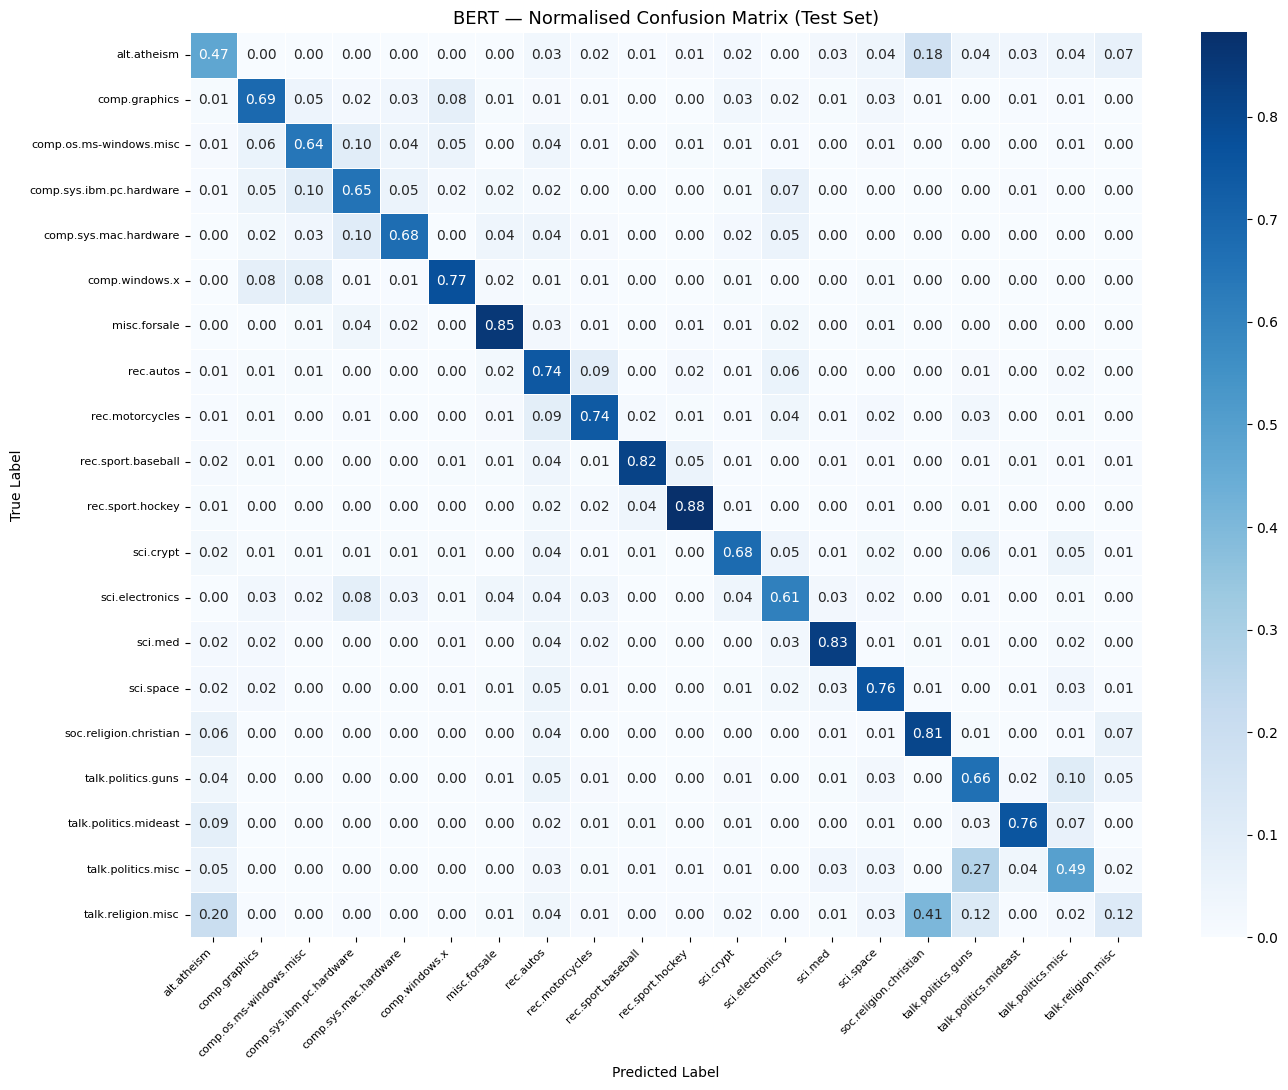

Saved & logged: figures/task2_bert_confusion_matrix.png


In [16]:
cm      = confusion_matrix(test_labels_arr, test_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)  # row-normalise

# ── Matplotlib version (saved locally) ───────────────────────────
fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(
    cm_norm, annot=True, fmt=".2f", cmap="Blues",
    xticklabels=TARGET_NAMES, yticklabels=TARGET_NAMES,
    ax=ax, linewidths=0.4,
)
ax.set_title("BERT — Normalised Confusion Matrix (Test Set)", fontsize=13)
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
cm_path = os.path.join(FIGURES_DIR, "task2_bert_confusion_matrix.png")
plt.savefig(cm_path, dpi=150)
plt.show()

# ── W&B interactive confusion matrix ─────────────────────────────
# wandb.plot.confusion_matrix creates a zoomable, interactive version
# in the W&B dashboard — much better than a static PNG for 20 classes
wandb.log({
    # Static PNG for the report
    "confusion_matrix_plot": wandb.Image(cm_path),
    # Interactive confusion matrix widget
    "confusion_matrix": wandb.plot.confusion_matrix(
        probs=None,
        y_true=test_labels_arr.tolist(),
        preds=test_preds.tolist(),
        class_names=TARGET_NAMES,
    ),
})
print(f"Saved & logged: {cm_path}")

## Cell 11 — Results Comparison Table

In [17]:
# Fill in Task 1 values once available
results = pd.DataFrame([
    {"Model": "NN + Word2Vec (1 epoch)",  "Test Acc": 0.2566, "Macro F1": 0.2247},
    {"Model": "NN + Word2Vec (N epochs)", "Test Acc": 0.6210, "Macro F1": 0.6017},
    {"Model": "NN + TF-IDF",              "Test Acc": 0.6001, "Macro F1": 0.5821},
    {"Model": "NN + Experiment (1d)",     "Test Acc": 0.6402, "Macro F1": 0.6237},
    {"Model": f"BERT-base ep={NUM_EPOCHS} lr={LR}",
     "Test Acc": round(test_acc, 4), "Macro F1": round(macro_f1, 4)},
])
print(results.to_string(index=False))

# Log comparison as a W&B Table
comparison_table = wandb.Table(dataframe=results.fillna("TBD"))
wandb.log({"model_comparison": comparison_table})

print("Comparison table logged to W&B.")

                   Model  Test Acc  Macro F1
 NN + Word2Vec (1 epoch)    0.2566    0.2247
NN + Word2Vec (N epochs)    0.6210    0.6017
             NN + TF-IDF    0.6001    0.5821
    NN + Experiment (1d)    0.6402    0.6237
 BERT-base ep=3 lr=2e-05    0.6986    0.6811
Comparison table logged to W&B.


## Cell 12 — Experiment Runner

Each call to `run_experiment()` creates its **own W&B run** — all runs appear in the same project so you can compare them side-by-side in the W&B dashboard.

| Experiment | Change | Hypothesis |
|---|---|---|
| A | `max_len=256` | More context per article |
| B | `lr=5e-5` | Faster convergence |
| C | `num_epochs=5` | More updates on domain text |
| D | `freeze_layers=6` | Preserve low-level BERT features |
| E | `dropout=0.3` | Stronger regularisation |

In [18]:
def run_experiment(exp_name, num_epochs=3, lr=2e-5, max_len=128,
                   dropout=0.1, freeze_layers=0):
    """
    Train a fresh BERT model with custom hyperparameters.
    Each call creates its own W&B run in the same project.

    Args:
        exp_name      : label shown in W&B dashboard
        num_epochs    : training epochs
        lr            : AdamW learning rate
        max_len       : tokenizer max sequence length
        dropout       : hidden_dropout_prob
        freeze_layers : freeze this many bottom encoder layers (0 = train all)

    Returns:
        dict with Test Acc, Macro F1, and W&B run URL
    """
    print(f"\n{'='*55}\nExperiment: {exp_name}\n{'='*55}")

    # ── Start a new W&B run for this experiment ───────────────────
    exp_run = wandb.init(
        project=WANDB_PROJECT,
        name=exp_name,
        tags=["experiment", "bert"],
        config={
            "model":         MODEL_NAME,
            "max_len":       max_len,
            "num_epochs":    num_epochs,
            "lr":            lr,
            "dropout":       dropout,
            "freeze_layers": freeze_layers,
            "batch_size":    BATCH_SIZE,
        },
        reinit=True,   # allows multiple wandb.init() calls in same notebook
    )
    print(f"W&B run: {exp_run.url}")

    # Build loaders (re-tokenize if max_len differs)
    tok = BertTokenizer.from_pretrained(MODEL_NAME)
    loaders = {
        "train": DataLoader(NewsGroupDataset(train_texts, train_labels, tok, max_len),
                            batch_size=BATCH_SIZE, shuffle=True,  num_workers=0),
        "val":   DataLoader(NewsGroupDataset(val_texts,   val_labels,   tok, max_len),
                            batch_size=BATCH_SIZE, shuffle=False, num_workers=0),
        "test":  DataLoader(NewsGroupDataset(test_texts,  test_labels,  tok, max_len),
                            batch_size=BATCH_SIZE, shuffle=False, num_workers=0),
    }

    # Fresh model from pre-trained weights
    exp_model = BertForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=NUM_CLASSES, hidden_dropout_prob=dropout
    ).to(DEVICE)

    # Optionally freeze bottom encoder layers
    if freeze_layers > 0:
        for i, layer in enumerate(exp_model.bert.encoder.layer):
            if i < freeze_layers:
                for p in layer.parameters():
                    p.requires_grad = False
        frozen = sum(p.numel() for p in exp_model.parameters() if not p.requires_grad)
        print(f"  Frozen layers 0-{freeze_layers-1} ({frozen:,} params)")

    no_decay = ["bias", "LayerNorm.weight"]
    opt = AdamW(
        [
            {"params": [p for n, p in exp_model.named_parameters()
                        if p.requires_grad and not any(nd in n for nd in no_decay)],
             "weight_decay": WEIGHT_DECAY},
            {"params": [p for n, p in exp_model.named_parameters()
                        if p.requires_grad and any(nd in n for nd in no_decay)],
             "weight_decay": 0.0},
        ],
        lr=lr, eps=1e-8,
    )
    total = len(loaders["train"]) * num_epochs
    sched = get_linear_schedule_with_warmup(opt, int(total * WARMUP_RATIO), total)

    # Training loop with W&B logging
    for ep in range(1, num_epochs + 1):
        tr_loss, tr_acc       = train_one_epoch(exp_model, loaders["train"], opt, sched)
        vl_loss, vl_acc, _, _ = evaluate(exp_model, loaders["val"])
        wandb.log({
            "epoch":          ep,
            "train/loss":     tr_loss,
            "train/accuracy": tr_acc,
            "val/loss":       vl_loss,
            "val/accuracy":   vl_acc,
        })
        print(f"  Epoch {ep} | Train Acc: {tr_acc:.4f} | Val Acc: {vl_acc:.4f}")

    # Final test evaluation
    _, t_acc, t_preds, t_lbls = evaluate(exp_model, loaders["test"])
    m_f1 = f1_score(t_lbls, t_preds, average="macro")
    wandb.summary["test/accuracy"] = t_acc
    wandb.summary["test/macro_f1"] = m_f1
    print(f"  Test Acc: {t_acc:.4f} | Macro F1: {m_f1:.4f}")

    run_url = exp_run.url
    wandb.finish()   # close this experiment's run before the next one

    # Free memory
    del exp_model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return {"Experiment": exp_name,
            "Test Acc":   round(t_acc, 4),
            "Macro F1":   round(m_f1, 4),
            "W&B URL":    run_url}



res_B = run_experiment("LR=5e-5",         lr=5e-5)
res_D = run_experiment("Freeze-6-layers", freeze_layers=6)
res_A = run_experiment("MaxLen=256",       max_len=256)
res_E = run_experiment("Dropout=0.3",      dropout=0.3)
print("Experiment runner ready. Uncomment lines above to run.")


Experiment: LR=5e-5


best_val_accuracy,▁▆█
epoch,▁▁▅▅██
epoch_time_sec,▁▆█
learning_rate,█▅▁
train/accuracy,▁▆█
train/loss,█▃▁
val/accuracy,▁▆█
val/loss,█▂▁
best_val_accuracy,0.7553
epoch,3
epoch_time_sec,256.34475


wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


W&B run: https://wandb.ai/likhita-kolli-hochschule-luzern/nalapro-task2-bert/runs/laz5y01y


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Epoch 1 | Train Acc: 0.3523 | Val Acc: 0.6228
  Epoch 2 | Train Acc: 0.6331 | Val Acc: 0.6943
  Epoch 3 | Train Acc: 0.6938 | Val Acc: 0.7067
  Test Acc: 0.6686 | Macro F1: 0.6420


epoch,▁▅█
train/accuracy,▁▇█
train/loss,█▂▁
val/accuracy,▁▇█
val/loss,█▂▁
epoch,3
test/accuracy,0.66861
test/macro_f1,0.642
train/accuracy,0.69377
train/loss,1.01175
val/accuracy,0.70671


Experiment runner ready. Uncomment lines above to run.


## Cell 13 — Experiment Comparison Chart

            Experiment  Test Acc  Macro F1
Baseline ep=3 lr=2e-05    0.6986    0.6811


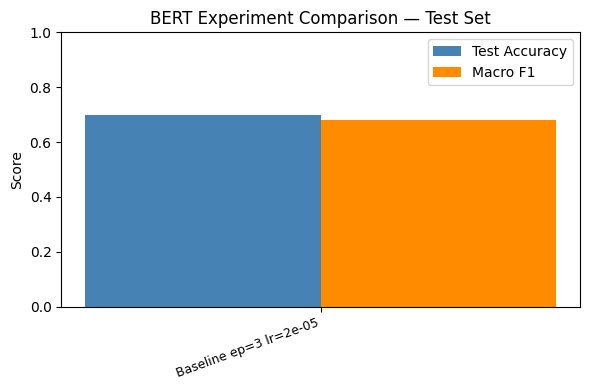

Saved & logged: figures/task2_bert_experiment_comparison.png


In [20]:
if wandb.run is None:
    wandb.init(project=WANDB_PROJECT, id=run.id, resume="allow")
# Add completed experiment dicts here after running run_experiment()
experiment_results = [
    {"Experiment": f"Baseline ep={NUM_EPOCHS} lr={LR}",
     "Test Acc": round(test_acc, 4), "Macro F1": round(macro_f1, 4)},
    # res_B,
    # res_D,
]

exp_df = pd.DataFrame(experiment_results)
print(exp_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(max(6, len(exp_df) * 2), 4))
x, w = np.arange(len(exp_df)), 0.35
ax.bar(x - w/2, exp_df["Test Acc"], width=w, label="Test Accuracy", color="steelblue")
ax.bar(x + w/2, exp_df["Macro F1"],  width=w, label="Macro F1",      color="darkorange")
ax.set_xticks(x)
ax.set_xticklabels(exp_df["Experiment"], rotation=20, ha="right", fontsize=9)
ax.set_ylim(0, 1)
ax.set_ylabel("Score")
ax.set_title("BERT Experiment Comparison — Test Set")
ax.legend()
plt.tight_layout()
bar_path = os.path.join(FIGURES_DIR, "task2_bert_experiment_comparison.png")
plt.savefig(bar_path, dpi=150)
plt.show()

# Log the comparison chart to W&B
wandb.log({"experiment_comparison": wandb.Image(bar_path)})
print(f"Saved & logged: {bar_path}")

## Cell 14 — Finish W&B Run

In [21]:
# Always call wandb.finish() at the very end.
# This flushes all remaining logs, marks the run as 'Finished'
# in the dashboard, and prints the final public URL.
wandb.finish()
print(f"\nW&B run complete: {run.url}")
print("Paste the URL above into the header cell of this notebook.")

best_val_accuracy,0.7553
epoch,3
epoch_time_sec,256.34475
learning_rate,0
test/accuracy,0.69862
test/loss,1.03276
test/macro_f1,0.68115
test/weighted_f1,0.6954
train/accuracy,0.82459
train/loss,0.62544
+3,...



W&B run complete: https://wandb.ai/likhita-kolli-hochschule-luzern/nalapro-task2-bert/runs/hw85yqc0
Paste the URL above into the header cell of this notebook.
